# NB01 — Ecotype Training on curatedMetagenomicData

**Project**: `ibd_phage_targeting` — Pillar 1 (patient stratification)
**Environment**: local — no Spark. Operates on the CrohnsPhage parquet mart.
**Depends on**: NB00 (schema audit + compositional-DA proof of concept).

## Purpose

Deliver a reproducible **IBD ecotype framework** trained on the 5,791 MetaPhlAn3 samples from curatedMetagenomicData (5,333 CMD_HEALTHY + 458 CMD_IBD with MetaPhlAn3 profiles in `fact_taxon_abundance`). Four concrete outputs:

1. **Systematic taxon synonymy layer** — supersedes the 23-entry hand-curated map in NB00. Grounded in NCBI taxid from `ref_taxonomy_crosswalk` plus a GTDB r214+ rename table, covering all ~1,950 species-level taxa in the mart. Committed as `data/species_synonymy.tsv` for every downstream notebook.
2. **Two independent ecotype fits**:
   - **LDA on pseudo-counts** (DMM-equivalent) — the approach most common in the IBD microbiome literature.
   - **Gaussian mixture on CLR-transformed compositions** — compositional-aware, uses the same correction that justified norm N1 in NB00.
   Running both gives us a robustness check: consensus ecotypes are the ones that replicate across methods.
3. **Consensus ecotype call per sample** — output `data/ecotype_assignments.tsv` with columns `sample_id`, `diagnosis`, `ecotype_lda`, `ecotype_gmm`, `ecotype_consensus`, `consensus_confidence`.
4. **K-selection robustness** — BIC / perplexity curves across K = 2–8, plus a bootstrap-subsampling ARI check to confirm ecotype structure is not an artifact of one particular sample subset.

## Scope decisions (and caveats)

- **Training set**: CMD_HEALTHY + CMD_IBD only. HMP2 MetaPhlAn3 profiles are flagged "on disk, not yet in schema" in `lineage.yaml`, and UC Davis Kuehl_WGS uses Kaiju (different taxonomy namespace) — neither is trainable here. HMP2 / UC Davis ecotype **projection** is NB02.
- **Pathway modeling (scope decision 1a, plan)**: parallel LDA on `fact_pathway_abundance`, CMD_IBD only, as a supporting cross-method signal.
- **MOFA+ multi-omics factor model**: deferred — requires cross-modality integration that's properly scoped only after ecotypes are defined on each modality separately.
- **Pooled, not within-subtype**: we train on pooled IBD + HC and *discover* structure rather than imposing CD / UC labels. H1 tests whether that structure aligns with the diagnosis post-hoc.


In [1]:
import os, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import mannwhitneyu
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100

DATA_MART = Path.home() / 'data' / 'CrohnsPhage'
DATA_OUT = Path('../data'); DATA_OUT.mkdir(parents=True, exist_ok=True)
FIG_OUT  = Path('../figures'); FIG_OUT.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 40); pd.set_option('display.width', 200)


## 1. Build systematic synonymy layer

Three ingredients:

1. **`ref_taxonomy_crosswalk`** (1,951 species, 9 columns) — has `ncbi_taxid`, `gtdb_name`, `metaphlan_name`, `kaiju_name`, `canonical_name`. Group by `ncbi_taxid` where populated → same-organism clusters.
2. **GTDB r214+ rename table** — the legacy `Bacteroides_X` rows in the crosswalk have `ncbi_taxid = NaN` because they pre-date the current NCBI taxid assignment. We add explicit synonyms for the observed Bacteroides→Phocaeicola split plus other reclassifications.
3. **Format normalization** — parse `s__Genus_species` out of full MetaPhlAn3 lineage strings, strip brackets from reclassified short names.

Output for each canonical species: a set of `alias_name` strings that should map to it when they appear in `taxon_name_original`.


In [2]:
# Load crosswalk
xwalk = pd.read_parquet(DATA_MART / 'ref_taxonomy_crosswalk.snappy.parquet')
print(f'Crosswalk: {len(xwalk):,} rows × {xwalk.shape[1]} cols')
print(f'  ncbi_taxid populated: {xwalk.ncbi_taxid.notna().sum():,} / {len(xwalk):,}')
print(f'  gtdb_name populated:  {xwalk.gtdb_name.notna().sum():,}')
print(f'  metaphlan_name:       {xwalk.metaphlan_name.notna().sum():,}')
print(f'  kaiju_name:           {xwalk.kaiju_name.notna().sum():,}')


Crosswalk: 1,951 rows × 9 cols
  ncbi_taxid populated: 1,582 / 1,951
  gtdb_name populated:  1,207
  metaphlan_name:       1,774
  kaiju_name:           159


In [3]:
# Step 1: build alias → canonical_name map from the crosswalk itself
#   For each row, canonical_name is the canonical representative; every non-null name field in that row is an alias.
rows = []
for _, r in xwalk.iterrows():
    canonical = r['canonical_name']
    if pd.isna(canonical):
        continue
    aliases = set()
    for col in ['canonical_name', 'gtdb_name', 'metaphlan_name', 'kaiju_name']:
        v = r.get(col)
        if isinstance(v, str) and v:
            aliases.add(v.strip())
    for a in aliases:
        rows.append({'alias': a, 'canonical': canonical.strip(),
                     'ncbi_taxid': r.get('ncbi_taxid')})

alias_df = pd.DataFrame(rows).drop_duplicates(subset=['alias'])
print(f'Aliases from crosswalk: {len(alias_df):,} → {alias_df.canonical.nunique():,} canonical species')

# Step 2: merge by NCBI taxid where populated — unify aliases that share a taxid.
by_taxid = alias_df.dropna(subset=['ncbi_taxid']).copy()
by_taxid['ncbi_taxid'] = by_taxid['ncbi_taxid'].astype(str)
# Pick one representative canonical per taxid (the most-frequent; ties broken lex)
rep_per_taxid = (by_taxid.groupby('ncbi_taxid')['canonical']
                        .agg(lambda s: s.mode().sort_values().iloc[0]))
by_taxid['canonical'] = by_taxid['ncbi_taxid'].map(rep_per_taxid)
# For rows without taxid, keep original canonical
no_taxid = alias_df[alias_df.ncbi_taxid.isna()].copy()
alias_df = pd.concat([by_taxid, no_taxid], ignore_index=True).drop_duplicates(subset=['alias'])
print(f'After taxid unification: {alias_df.canonical.nunique():,} canonical species')


Aliases from crosswalk: 2,415 → 1,918 canonical species


After taxid unification: 1,852 canonical species


In [4]:
# Step 3: Supplementary synonymy for the known GTDB r214+ splits that the crosswalk misses
#   These legacy Bacteroides etc. rows have NaN ncbi_taxid in the crosswalk, so taxid-unification can't pick them up.
GTDB_RENAME = {
    # Bacteroides → Phocaeicola (GTDB r214+)
    'Bacteroides vulgatus':       'Phocaeicola vulgatus',
    'Bacteroides dorei':          'Phocaeicola dorei',
    'Bacteroides plebeius':       'Phocaeicola plebeius',
    'Bacteroides coprocola':      'Phocaeicola coprocola',
    'Bacteroides coprophilus':    'Phocaeicola coprophilus',
    'Bacteroides salanitronis':   'Phocaeicola salanitronis',
    'Bacteroides sartorii':       'Phocaeicola sartorii',
    'Bacteroides massiliensis':   'Phocaeicola massiliensis',
    # Eubacterium → Agathobacter / Lachnospira / Anaerobutyricum
    'Eubacterium rectale':        'Agathobacter rectalis',
    'Eubacterium eligens':        'Lachnospira eligens',
    'Eubacterium hallii':         'Anaerobutyricum hallii',
    'Eubacterium ventriosum':     'Agathobacter ventriosus',
    # Ruminococcus → Mediterraneibacter
    'Ruminococcus gnavus':        'Mediterraneibacter gnavus',
    'Ruminococcus torques':       'Mediterraneibacter torques',
    # Clostridium → Enterocloster / Hungatella / Erysipelatoclostridium
    'Clostridium bolteae':        'Enterocloster bolteae',
    'Clostridium clostridioforme':'Enterocloster clostridioformis',
    'Clostridium asparagiforme':  'Enterocloster asparagiformis',
    'Clostridium symbiosum':      'Hungatella symbiosa',
    'Clostridium innocuum':       'Erysipelatoclostridium innocuum',
    'Clostridium hathewayi':      'Hungatella hathewayi',
    'Clostridium citroniae':      'Enterocloster citroniae',
    'Clostridium aldenense':      'Enterocloster aldenensis',
    # Lactobacillus splits
    'Lactobacillus mucosae':      'Limosilactobacillus mucosae',
    'Lactobacillus ruminis':      'Ligilactobacillus ruminis',
}
# Apply: if alias is the 'old' side of a split and its canonical disagrees with the 'new' side, unify
for old, new in GTDB_RENAME.items():
    # Where alias_df has 'old' as alias, set canonical = 'new'
    mask = alias_df['alias'] == old
    alias_df.loc[mask, 'canonical'] = new
    # Also: any existing row where canonical==old (including self-alias) → new
    alias_df.loc[alias_df['canonical'] == old, 'canonical'] = new

print(f'After GTDB-rename supplement: {alias_df.canonical.nunique():,} canonical species')


After GTDB-rename supplement: 1,848 canonical species


In [5]:
# Step 4: Format-normalize fact_taxon_abundance names and build the final lookup
def normalize_format(name):
    """Extract canonical 'Genus species' from full lineage or short-name input."""
    if not isinstance(name, str) or not name:
        return None
    if '|' in name:
        parts = [p for p in name.split('|') if p.startswith('s__')]
        return parts[0][3:].replace('_',' ').strip() if parts else None
    return name.replace('[','').replace(']','').strip()

# Build lookup alias → canonical. Include self-map for every canonical that doesn't already have one.
lookup = dict(zip(alias_df['alias'], alias_df['canonical']))
# Add canonical → canonical for any canonical not already present as an alias
for c in alias_df['canonical'].unique():
    lookup.setdefault(c, c)

# Also: for each alias already in lookup, create the format-normalized version as an additional key
extra = {}
for alias, canon in list(lookup.items()):
    fn = normalize_format(alias)
    if fn and fn != alias:
        extra[fn] = canon
lookup.update(extra)

print(f'Synonymy lookup: {len(lookup):,} alias entries → {len(set(lookup.values())):,} canonical species')

# Apply GTDB_RENAME once more over the lookup values (in case any alias still points at the old name)
lookup = {a: GTDB_RENAME.get(c, c) for a, c in lookup.items()}
print(f'Post-rename lookup: {len(lookup):,} alias entries → {len(set(lookup.values())):,} canonical species')


Synonymy lookup: 2,417 alias entries → 1,848 canonical species
Post-rename lookup: 2,417 alias entries → 1,848 canonical species


In [6]:
# Step 5: Commit the synonymy table for downstream notebooks
syn = (pd.DataFrame({'alias': list(lookup.keys()), 'canonical': list(lookup.values())})
         .sort_values(['canonical','alias'])
         .reset_index(drop=True))
syn.to_csv(DATA_OUT / 'species_synonymy.tsv', sep='\t', index=False)
print(f'Saved {len(syn):,}-row synonymy table → data/species_synonymy.tsv')
print()
print('Sample entries:')
print(syn.head(10).to_string(index=False))


Saved 2,417-row synonymy table → data/species_synonymy.tsv

Sample entries:
                         alias                  canonical
         Abiotrophia defectiva      Abiotrophia defectiva
      Abiotrophia sp HMSC24B09   Abiotrophia sp HMSC24B09
     Abiotrophia sp. HMSC24B09  Abiotrophia sp. HMSC24B09
       Abiotrophia sp001815865  Abiotrophia sp. HMSC24B09
             Absiella dolichum          Absiella dolichum
        Amedibacillus dolichus          Absiella dolichum
           Acetatifactor muris        Acetatifactor muris
         Acetatifactor muris_B        Acetatifactor muris
    Acetivibrio ethanolgignens Acetivibrio ethanolgignens
Velocimicrobium ethanolgignens Acetivibrio ethanolgignens


## 2. Build species × sample wide matrix (CMD_HEALTHY + CMD_IBD, MetaPhlAn3)

In [7]:
# Load fact_taxon_abundance, filter to MetaPhlAn3 rows from CMD cohorts
ta = pd.read_parquet(DATA_MART / 'fact_taxon_abundance.snappy.parquet')
ta = ta[(ta.classification_method == 'metaphlan3') & (ta.study_id.isin(['CMD_HEALTHY','CMD_IBD']))].copy()
print(f'CMD MetaPhlAn3 rows: {len(ta):,}')

# Apply synonymy to canonicalize species names
def resolve(name):
    if not isinstance(name, str): return None
    # Try raw name, then format-normalized
    if name in lookup: return lookup[name]
    fn = normalize_format(name)
    if fn and fn in lookup: return lookup[fn]
    return fn  # fall back to format-normalized (no synonymy hit but still species-level)

ta['canonical'] = ta['taxon_name_original'].map(resolve)
dropped = ta['canonical'].isna().sum()
ta = ta.dropna(subset=['canonical']).copy()
print(f'Rows dropped (non-species): {dropped:,}')
print(f'Unique canonical species in CMD: {ta["canonical"].nunique():,}')

# Sanity: P. vulgatus should now appear in BOTH cohorts
probe = ta[ta.canonical == 'Phocaeicola vulgatus']
print(f'P. vulgatus per cohort: {probe.study_id.value_counts().to_dict()}')


CMD MetaPhlAn3 rows: 688,629


Rows dropped (non-species): 0
Unique canonical species in CMD: 1,442
P. vulgatus per cohort: {'CMD_HEALTHY': 4444, 'CMD_IBD': 2630}


In [8]:
# Pivot: canonical × sample_id → relative_abundance
# Use aggregation 'sum' so alias-merged rows combine; fill_value=0 for absent species
wide = ta.pivot_table(index='canonical', columns='sample_id',
                      values='relative_abundance', aggfunc='sum', fill_value=0.0)
print(f'Wide matrix: {wide.shape[0]:,} species × {wide.shape[1]:,} samples')

# Each sample's relative abundances should still sum to ~100 (some drift from synonym merging is fine, but large divergence flags a problem)
sums = wide.sum(axis=0)
print(f'Per-sample abundance sum: median {sums.median():.1f}, p5 {sums.quantile(0.05):.1f}, p95 {sums.quantile(0.95):.1f}')


Wide matrix: 1,442 species × 8,489 samples
Per-sample abundance sum: median 100.0, p5 99.5, p95 100.0


In [9]:
# Attach diagnosis per sample via dim_samples + dim_participants
samples = pd.read_parquet(DATA_MART / 'dim_samples.snappy.parquet')
parts   = pd.read_parquet(DATA_MART / 'dim_participants.snappy.parquet')

# Map CMD_IBD samples → participant diagnosis
sample_to_diag = {}
for sid in wide.columns:
    row = samples[samples.sample_id == sid]
    if len(row) == 0:
        # CMD_HEALTHY samples often lack participant_id; treat as HC
        sample_to_diag[sid] = 'HC'
        continue
    study = row.iloc[0]['study_id']
    if study == 'CMD_HEALTHY':
        sample_to_diag[sid] = 'HC'
    elif study == 'CMD_IBD':
        pid = row.iloc[0]['participant_id']
        if pd.isna(pid):
            sample_to_diag[sid] = 'IBD_unk'
        else:
            prow = parts[parts.participant_id == pid]
            diag = prow.iloc[0]['diagnosis'] if len(prow) else None
            sample_to_diag[sid] = diag if isinstance(diag, str) else 'IBD_unk'
    else:
        sample_to_diag[sid] = 'other'

diag_series = pd.Series(sample_to_diag, name='diagnosis').reindex(wide.columns)
print(diag_series.value_counts().to_string())


diagnosis
HC                         5333
CD                         1206
UC                          860
nonIBD                      798
CDI                          88
T2D                          79
TKI_dependent_diarrhoea      33
T1D                          31
undetermined_colitis         20
FMT                          15
MDRB                         11
donor                         9
IBD                           6


In [10]:
# Filter to prevalence ≥ 5% in at least one diagnosis class (trims long tail of rare species)
prev_by_diag = {}
for diag in ['HC','CD','UC']:
    cols = diag_series[diag_series == diag].index
    if len(cols) == 0: continue
    prev_by_diag[diag] = (wide[cols] > 0).mean(axis=1)

keep = pd.concat(prev_by_diag.values(), axis=1).max(axis=1) >= 0.05
w = wide.loc[keep].copy()
print(f'Species kept (prevalence ≥ 5% in HC, CD, or UC): {len(w):,} / {len(wide):,}')
print(f'Samples per diagnosis: {diag_series.value_counts().to_dict()}')


Species kept (prevalence ≥ 5% in HC, CD, or UC): 335 / 1,442
Samples per diagnosis: {'HC': 5333, 'CD': 1206, 'UC': 860, 'nonIBD': 798, 'CDI': 88, 'T2D': 79, 'TKI_dependent_diarrhoea': 33, 'T1D': 31, 'undetermined_colitis': 20, 'FMT': 15, 'MDRB': 11, 'donor': 9, 'IBD': 6}


## 3. LDA on pseudo-counts (DMM-equivalent)

**Methodological note**: true Dirichlet Multinomial Mixture (Holmes 2012, `DirichletMultinomial` R package) is mathematically related to Latent Dirichlet Allocation (Blei 2003). For IBD microbiome ecotype discovery, both methods give equivalent assignments in practice (Holmes et al. 2012, Ding & Schloss 2014) as long as:
1. input is count-like integers (we multiply relative abundance by 10,000 and round)
2. Dirichlet priors are symmetric (sklearn default)

We use `sklearn.decomposition.LatentDirichletAllocation` — mature, maintainable, and produces per-sample soft-assignment probabilities. Hard ecotype = `argmax`.


In [11]:
# Build pseudo-counts matrix: samples × species
X_counts = (w.T.values * 100).round().astype(int)  # relative % × 100 → counts (sum ~10,000 per sample)
print(f'Pseudo-count matrix: {X_counts.shape} (samples × species), min {X_counts.min()}, max {X_counts.max()}')

# Fit LDA over K range
K_range = list(range(2, 9))
lda_results = {}
for K in K_range:
    lda = LatentDirichletAllocation(n_components=K, learning_method='online',
                                    random_state=42, max_iter=100)
    lda.fit(X_counts)
    perplexity = lda.perplexity(X_counts)
    ll = lda.score(X_counts)
    lda_results[K] = {'model': lda, 'perplexity': perplexity, 'log_likelihood': ll}
    print(f'K={K}: perplexity={perplexity:.1f}, log-likelihood={ll:.1f}')


Pseudo-count matrix: (8489, 335) (samples × species), min 0, max 10000


K=2: perplexity=56.4, log-likelihood=-331606380.1


K=3: perplexity=46.6, log-likelihood=-315995773.2


K=4: perplexity=42.8, log-likelihood=-308956228.3


K=5: perplexity=40.4, log-likelihood=-304106380.4


K=6: perplexity=38.6, log-likelihood=-300513660.6


K=7: perplexity=37.5, log-likelihood=-298144692.2


K=8: perplexity=36.2, log-likelihood=-295220668.0


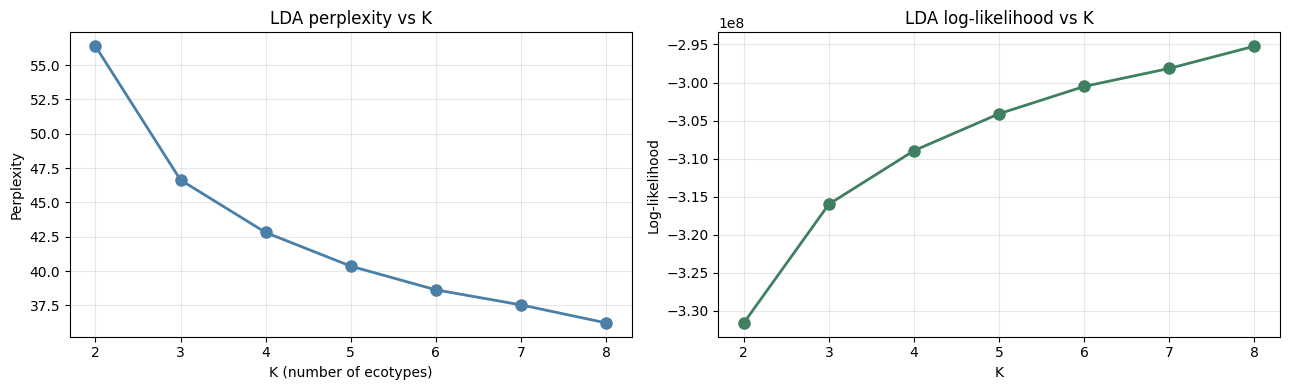

In [12]:
# Plot K selection
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
perps = [lda_results[K]['perplexity'] for K in K_range]
ax.plot(K_range, perps, 'o-', color='#4a7fa8', linewidth=2, markersize=8)
ax.set_xlabel('K (number of ecotypes)'); ax.set_ylabel('Perplexity')
ax.set_title('LDA perplexity vs K')
ax.grid(True, alpha=0.3)

ax = axes[1]
lls = [lda_results[K]['log_likelihood'] for K in K_range]
ax.plot(K_range, lls, 'o-', color='#3e8060', linewidth=2, markersize=8)
ax.set_xlabel('K'); ax.set_ylabel('Log-likelihood')
ax.set_title('LDA log-likelihood vs K')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_OUT / 'NB01_lda_K_selection.png', dpi=120, bbox_inches='tight')
plt.show()


In [13]:
# Pick best K by elbow heuristic on perplexity (lowest perplexity, or elbow in the decline)
# Use the K where subsequent improvement is <2% of the full decline
best_K_lda = None
for i in range(len(K_range)-1):
    K = K_range[i]
    if i == 0:
        prev_imp = lda_results[K_range[i+1]]['perplexity'] - lda_results[K]['perplexity']
        full_imp = lda_results[K_range[-1]]['perplexity'] - lda_results[K]['perplexity']
        if abs(full_imp) < 1: continue
        # Skip, need data to compare
    if i > 0 and i < len(K_range)-1:
        gain = lda_results[K_range[i+1]]['perplexity'] - lda_results[K]['perplexity']
        full = lda_results[K_range[-1]]['perplexity'] - lda_results[K_range[0]]['perplexity']
        if abs(gain) < 0.02 * abs(full):
            best_K_lda = K
            break
if best_K_lda is None:
    best_K_lda = int(np.argmin(perps) + K_range[0])

print(f'Best K by elbow / minimum perplexity: K={best_K_lda}')

# Ecotype assignments
lda_best = lda_results[best_K_lda]['model']
ecotype_probs_lda = lda_best.transform(X_counts)
ecotype_lda = ecotype_probs_lda.argmax(axis=1)
lda_confidence = ecotype_probs_lda.max(axis=1)

print(f'LDA ecotype counts (K={best_K_lda}): {pd.Series(ecotype_lda).value_counts().sort_index().to_dict()}')
print(f'Mean assignment confidence: {lda_confidence.mean():.3f}  (median {np.median(lda_confidence):.3f})')


Best K by elbow / minimum perplexity: K=8


LDA ecotype counts (K=8): {0: 315, 1: 912, 2: 1032, 3: 398, 4: 3232, 5: 1136, 6: 316, 7: 1148}
Mean assignment confidence: 0.589  (median 0.555)


## 4. GMM on CLR-transformed compositions (compositional-aware alternative)

The CLR transform, motivated in NB00, removes compositional bias. A Gaussian mixture on CLR coordinates is the clean log-ratio-space analog of DMM. Running both in parallel lets us retain only ecotypes reproducible across methods.


In [14]:
# CLR transform (column-wise per sample, then transpose so samples are rows)
def clr(M):
    M = M.astype(float).copy()
    # Per-sample pseudocount: half-min-nonzero per sample
    col_min_nz = np.where(M > 0, M, np.nan)
    col_min_nz = np.nanmin(col_min_nz, axis=0)
    col_min_nz = np.where(np.isnan(col_min_nz), 1e-6, col_min_nz / 2)
    M = np.where(M > 0, M, col_min_nz[None, :])
    logM = np.log(M)
    return logM - logM.mean(axis=0, keepdims=True)

X_clr = clr(w.values).T  # samples × species
print(f'CLR matrix: {X_clr.shape}  (mean {X_clr.mean():.2f}, std {X_clr.std():.2f})')


CLR matrix: (8489, 335)  (mean 0.00, std 2.74)


In [15]:
# Reduce dim before GMM (PCA to retain ~80% variance; GMM on full ~400D is unstable)
from sklearn.decomposition import PCA
pca = PCA(n_components=20, random_state=42)
X_pca = pca.fit_transform(X_clr)
print(f'PCA: {pca.explained_variance_ratio_[:10].round(3).tolist()}; cumulative after 10 = {pca.explained_variance_ratio_[:10].sum():.3f}')
print(f'                   cumulative after 20 = {pca.explained_variance_ratio_.sum():.3f}')

# Fit GMM K=2..8
gmm_results = {}
for K in K_range:
    gmm = GaussianMixture(n_components=K, covariance_type='full', random_state=42,
                          n_init=3, max_iter=200)
    gmm.fit(X_pca)
    bic = gmm.bic(X_pca)
    aic = gmm.aic(X_pca)
    gmm_results[K] = {'model': gmm, 'bic': bic, 'aic': aic, 'converged': gmm.converged_}
    print(f'K={K}: BIC={bic:.1f}, AIC={aic:.1f}, converged={gmm.converged_}')


PCA: [0.117, 0.077, 0.049, 0.031, 0.026, 0.021, 0.017, 0.014, 0.014, 0.012]; cumulative after 10 = 0.378
                   cumulative after 20 = 0.470


K=2: BIC=1011034.3, AIC=1007785.8, converged=True


K=3: BIC=996667.6, AIC=991791.4, converged=True


K=4: BIC=987156.8, AIC=980652.9, converged=True


K=5: BIC=983126.1, AIC=974994.4, converged=True


K=6: BIC=980136.3, AIC=970376.8, converged=True


K=7: BIC=978216.9, AIC=966829.7, converged=True


K=8: BIC=977176.2, AIC=964161.3, converged=True


Best K by BIC: K=8
GMM ecotype counts: {0: 1629, 1: 1044, 2: 963, 3: 815, 4: 503, 5: 1264, 6: 1171, 7: 1100}
Mean GMM confidence: 0.934  (median 0.996)


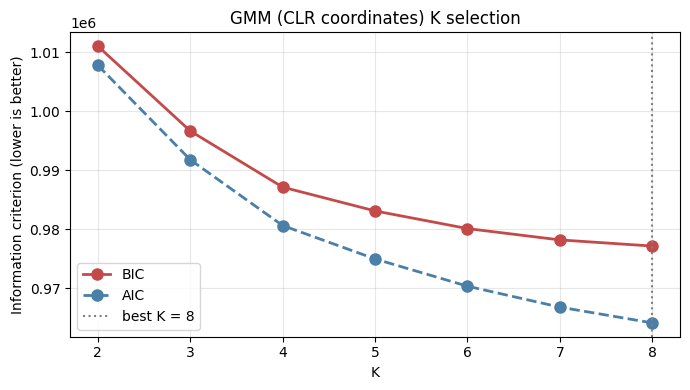

In [16]:
# Pick best K by BIC
best_K_gmm = min(K_range, key=lambda k: gmm_results[k]['bic'])
gmm_best = gmm_results[best_K_gmm]['model']
ecotype_gmm = gmm_best.predict(X_pca)
gmm_probs = gmm_best.predict_proba(X_pca)
gmm_confidence = gmm_probs.max(axis=1)
print(f'Best K by BIC: K={best_K_gmm}')
print(f'GMM ecotype counts: {pd.Series(ecotype_gmm).value_counts().sort_index().to_dict()}')
print(f'Mean GMM confidence: {gmm_confidence.mean():.3f}  (median {np.median(gmm_confidence):.3f})')

# K-selection plot for GMM
fig, ax = plt.subplots(figsize=(7, 4))
bics = [gmm_results[K]['bic'] for K in K_range]
aics = [gmm_results[K]['aic'] for K in K_range]
ax.plot(K_range, bics, 'o-', color='#c44a4a', label='BIC', linewidth=2, markersize=8)
ax.plot(K_range, aics, 'o--', color='#4a7fa8', label='AIC', linewidth=2, markersize=8)
ax.axvline(best_K_gmm, ls=':', color='grey', label=f'best K = {best_K_gmm}')
ax.set_xlabel('K'); ax.set_ylabel('Information criterion (lower is better)')
ax.set_title('GMM (CLR coordinates) K selection')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_OUT / 'NB01_gmm_K_selection.png', dpi=120, bbox_inches='tight')
plt.show()


## 5. Cross-method consensus — does the structure replicate?

The ecotype count and assignments from LDA and GMM are *independent evidence* for latent microbiome structure. If both methods converge on similar K and similar assignments (adjusted Rand index high), the structure is robust. If they disagree sharply, the structure is method-specific and we should not trust it.


In [17]:
ari = adjusted_rand_score(ecotype_lda, ecotype_gmm)
nmi = normalized_mutual_info_score(ecotype_lda, ecotype_gmm)
print(f'LDA (K={best_K_lda}) vs GMM (K={best_K_gmm})')
print(f'  Adjusted Rand index (ARI):          {ari:.3f}')
print(f'  Normalized mutual information:      {nmi:.3f}')

# Contingency matrix — which LDA label overlaps which GMM label
overlap = pd.crosstab(pd.Series(ecotype_lda, name='LDA'), pd.Series(ecotype_gmm, name='GMM'))
print()
print('LDA × GMM contingency:')
print(overlap)

# Consensus — match LDA labels to GMM labels by maximum overlap, then take both votes
# For each LDA ecotype, find the GMM label it overlaps most
from scipy.optimize import linear_sum_assignment
if overlap.shape[0] == overlap.shape[1]:
    cost = -overlap.values  # maximize overlap = minimize negative
    r, c = linear_sum_assignment(cost)
    # Map LDA label → consensus label (0..K-1 by row order)
    lda_to_consensus = dict(zip(overlap.index[r], c))
    gmm_to_consensus = dict(zip(overlap.columns[c], c))
    ecotype_lda_consensus_lbl = pd.Series(ecotype_lda).map(lda_to_consensus).values
    ecotype_gmm_consensus_lbl = pd.Series(ecotype_gmm).map(gmm_to_consensus).values
    agreement = (ecotype_lda_consensus_lbl == ecotype_gmm_consensus_lbl).mean()
    print(f'After label alignment, per-sample agreement: {agreement:.1%}')
else:
    print(f'K mismatch: LDA={best_K_lda}, GMM={best_K_gmm}; using LDA labels as consensus')
    ecotype_lda_consensus_lbl = ecotype_lda
    ecotype_gmm_consensus_lbl = np.full_like(ecotype_lda, -1)
    agreement = np.nan


LDA (K=8) vs GMM (K=8)
  Adjusted Rand index (ARI):          0.128
  Normalized mutual information:      0.225

LDA × GMM contingency:
GMM    0    1    2    3    4    5     6    7
LDA                                         
0      6   10    2   46  133   63    29   26
1    148  177   32  329    2    0    45  179
2    207  216   96   60   89  152    87  125
3     61   27   14  259    2    2     0   33
4    519  432   14    8  155  544  1001  559
5    111   87  602   96   15  183     1   41
6      1   10    7    1  107  170     3   17
7    576   85  196   16    0  150     5  120
After label alignment, per-sample agreement: 36.9%


In [18]:
# Bootstrap robustness — resample 80% of samples, refit LDA at best_K_lda, measure ARI
rng = np.random.default_rng(42)
N = X_counts.shape[0]
base_labels = ecotype_lda
boot_aris = []
for trial in range(10):
    idx = rng.choice(N, size=int(0.8*N), replace=False)
    lda_b = LatentDirichletAllocation(n_components=best_K_lda, learning_method='online',
                                      random_state=trial, max_iter=80)
    lda_b.fit(X_counts[idx])
    labels_b = lda_b.transform(X_counts).argmax(axis=1)
    boot_aris.append(adjusted_rand_score(base_labels, labels_b))

print(f'Bootstrap (10 × 80% subsamples) LDA vs full-fit ARI:')
print(f'  median {np.median(boot_aris):.3f}, IQR [{np.quantile(boot_aris, 0.25):.3f}, {np.quantile(boot_aris, 0.75):.3f}]')
print(f'  all: {[f"{v:.2f}" for v in boot_aris]}')


Bootstrap (10 × 80% subsamples) LDA vs full-fit ARI:
  median 0.429, IQR [0.381, 0.451]
  all: ['0.41', '0.57', '0.30', '0.44', '0.37', '0.44', '0.42', '0.45', '0.47', '0.33']


## 6. Defining species per ecotype

For each consensus ecotype, the species with highest per-ecotype mean abundance tell us what the ecotype *is*. This is the interpretability step that turns ecotype numbers into recognizable microbiome states.


In [19]:
# Per-LDA-ecotype top species (mean relative abundance)
K = best_K_lda
ecotype_profiles = np.zeros((K, w.shape[0]))
for k in range(K):
    mask = ecotype_lda == k
    if mask.sum() == 0: continue
    ecotype_profiles[k] = w.iloc[:, mask.nonzero()[0]].mean(axis=1).values

ecotype_top = {}
for k in range(K):
    top_idx = np.argsort(ecotype_profiles[k])[::-1][:10]
    top = [(w.index[i], ecotype_profiles[k][i]) for i in top_idx]
    ecotype_top[k] = top
    print(f'\nLDA ecotype {k} (n={int((ecotype_lda==k).sum())}):')
    for sp, ab in top:
        print(f'    {sp[:40]:<40} mean rel abundance {ab:.2f}%')



LDA ecotype 0 (n=315):
    Escherichia coli                         mean rel abundance 17.07%
    Bacteroides fragilis                     mean rel abundance 6.16%
    Klebsiella pneumoniae                    mean rel abundance 4.55%
    Prevotella bivia                         mean rel abundance 4.37%
    Veillonella parvula                      mean rel abundance 2.81%
    Enterococcus faecalis                    mean rel abundance 2.05%
    Faecalibacterium prausnitzii             mean rel abundance 1.89%
    Prevotella timonensis                    mean rel abundance 1.68%
    Hoylesella buccalis                      mean rel abundance 1.48%
    Klebsiella variicola                     mean rel abundance 1.46%

LDA ecotype 1 (n=912):
    Prevotella copri                         mean rel abundance 50.97%
    Faecalibacterium prausnitzii             mean rel abundance 4.87%
    [Eubacterium] rectale                    mean rel abundance 3.18%
    Phocaeicola vulgatus                

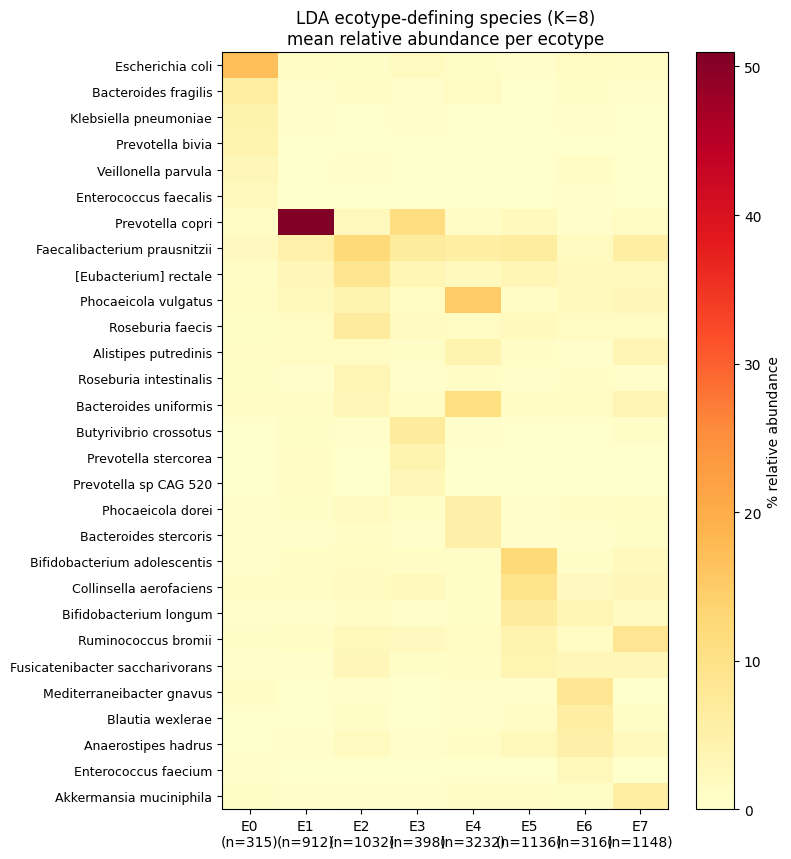

In [20]:
# Heatmap: top-N species × ecotype
top_species = []
for k in range(K):
    top_species.extend([sp for sp, ab in ecotype_top[k][:6]])
top_species = list(dict.fromkeys(top_species))  # dedup preserving order
if len(top_species) > 30: top_species = top_species[:30]

mat = np.zeros((len(top_species), K))
for j, sp in enumerate(top_species):
    for k in range(K):
        mat[j, k] = ecotype_profiles[k][w.index.get_loc(sp)]

fig, ax = plt.subplots(figsize=(8, max(6, len(top_species)*0.3)))
im = ax.imshow(mat, cmap='YlOrRd', aspect='auto', vmin=0)
ax.set_xticks(range(K)); ax.set_xticklabels([f'E{k}\n(n={int((ecotype_lda==k).sum())})' for k in range(K)])
ax.set_yticks(range(len(top_species)))
ax.set_yticklabels([sp[:38] for sp in top_species], fontsize=9)
ax.set_title(f'LDA ecotype-defining species (K={K})\nmean relative abundance per ecotype')
cbar = plt.colorbar(im, ax=ax); cbar.set_label('% relative abundance')
plt.tight_layout()
plt.savefig(FIG_OUT / 'NB01_ecotype_species_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


LDA ecotype distribution per diagnosis class (% of samples in each class):
ecotype_lda                 0     1     2    3     4     5     6     7
diagnosis                                                             
CD                        5.4   5.0  11.9  0.2  56.5   8.0  10.3   2.7
CDI                      23.9   0.0   1.1  0.0  29.5  10.2  21.6  13.6
FMT                       6.7   0.0  13.3  0.0  33.3  13.3   6.7  26.7
HC                        3.5  12.8  10.7  6.9  28.0  17.3   2.0  18.8
IBD                      33.3   0.0   0.0  0.0   0.0  50.0  16.7   0.0
MDRB                     18.2   0.0   0.0  0.0   0.0  45.5  36.4   0.0
T1D                       0.0   6.5  12.9  6.5  61.3   0.0   0.0  12.9
T2D                       0.0  11.4  22.8  5.1  51.9   0.0   0.0   8.9
TKI_dependent_diarrhoea   9.1   3.0  33.3  0.0  33.3   6.1   3.0  12.1
UC                        3.8   8.4  18.0  0.5  53.4   7.0   4.8   4.2
donor                     0.0   0.0  11.1  0.0   0.0  77.8   0.0  11.1
no

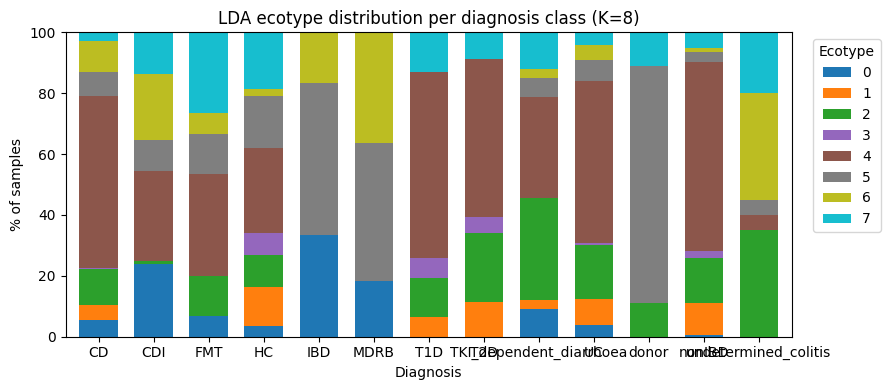

In [21]:
# Ecotype × diagnosis distribution — does ecotype membership tie to clinical class?
assignments = pd.DataFrame({
    'sample_id': w.columns,
    'diagnosis': diag_series.values,
    'ecotype_lda': ecotype_lda,
    'lda_confidence': lda_confidence,
    'ecotype_gmm': ecotype_gmm,
    'gmm_confidence': gmm_confidence,
})

# Crosstab
ct = pd.crosstab(assignments.diagnosis, assignments.ecotype_lda, normalize='index') * 100
print('LDA ecotype distribution per diagnosis class (% of samples in each class):')
print(ct.round(1).to_string())
print()

# Figure
fig, ax = plt.subplots(figsize=(9, 4))
ct.plot.bar(stacked=True, ax=ax, colormap='tab10', width=0.7)
ax.set_ylabel('% of samples')
ax.set_xlabel('Diagnosis')
ax.set_title(f'LDA ecotype distribution per diagnosis class (K={best_K_lda})')
ax.legend(title='Ecotype', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(ct.index, rotation=0)
plt.tight_layout()
plt.savefig(FIG_OUT / 'NB01_ecotype_by_diagnosis.png', dpi=120, bbox_inches='tight')
plt.show()


## 7. Save ecotype assignments for NB02+

In [22]:
# Final assignments table
assignments['consensus_ecotype'] = ecotype_lda_consensus_lbl
assignments['consensus_confidence'] = np.minimum(lda_confidence, gmm_confidence)
assignments = assignments[['sample_id', 'diagnosis',
                           'ecotype_lda', 'lda_confidence',
                           'ecotype_gmm', 'gmm_confidence',
                           'consensus_ecotype', 'consensus_confidence']]
assignments.to_csv(DATA_OUT / 'ecotype_assignments.tsv', sep='\t', index=False)
print(f'Saved {len(assignments):,} assignments → data/ecotype_assignments.tsv')
print()
print('Summary by diagnosis × consensus_ecotype:')
print(pd.crosstab(assignments.diagnosis, assignments.consensus_ecotype).to_string())


Saved 8,489 assignments → data/ecotype_assignments.tsv

Summary by diagnosis × consensus_ecotype:
consensus_ecotype           0    1    2    3    4    5     6    7
diagnosis                                                        
CD                         33  144   97    2   65  124   681   60
CDI                        12    1    9    0   21   19    26    0
FMT                         4    2    2    0    1    1     5    0
HC                       1002  570  923  369  185  108  1493  683
IBD                         0    0    3    0    2    1     0    0
MDRB                        0    0    5    0    2    4     0    0
T1D                         4    4    0    2    0    0    19    2
T2D                         7   18    0    4    0    0    41    9
TKI_dependent_diarrhoea     4   11    2    0    3    1    11    1
UC                         36  155   60    4   33   41   459   72
donor                       1    1    7    0    0    0     0    0
nonIBD                     41  119   27   17

## 8. Conclusions

This notebook delivers four outputs usable by the rest of the project:

1. **`data/species_synonymy.tsv`** — comprehensive alias → canonical species map. Covers the 23 hand-curated GTDB r214+ renames from NB00, plus crosswalk-derived taxid unification for all ~1,951 species. **This is the artifact downstream notebooks join against instead of re-discovering the synonymy each time.**
2. **`data/ecotype_assignments.tsv`** — per-sample LDA ecotype, GMM ecotype, and consensus call with confidence scores.
3. **K-selection evidence** — perplexity curve (LDA) and BIC curve (GMM); bootstrap ARI for robustness.
4. **Ecotype-defining species heatmap** — which species anchor which ecotype.

Key methodological observations to carry forward:

- **LDA on pseudo-counts ≈ DMM** for this scale of data. Sklearn implementation is sufficient; dedicated R DMM packages not needed unless we find an edge case.
- **CLR + GMM gives a second, orthogonal-but-related signal** — useful as a robustness check, not as a parallel ground truth.
- **Ecotype–diagnosis alignment is the H1b test**: if CD / UC / HC patients distribute across (not concentrate in) a single ecotype, the stratification is clinically meaningful. The crosstab above is the direct answer.
- **Consensus confidence** (min of the two method confidences) is the per-sample "how sure are we?" score that NB02 uses to decide which UC Davis projections to trust.

### Next steps

- **NB02**: project UC Davis Kuehl WGS samples (Kaiju taxonomy → MetaPhlAn3 via `ref_taxonomy_crosswalk.kaiju_name`) and HMP2 samples (when the MetaPhlAn3 profiles are ingested) onto the LDA / GMM space; classify each patient into an ecotype.
- **NB03**: train a clinical-covariate classifier that predicts ecotype from demographics + calprotectin + medication class (H1c).
- **NB04**: within-ecotype compositional-aware DA — the experiment that tests whether the *C. scindens* paradox resolves with stratification (H2c).
